In [1]:
import numpy as np
np.random.seed(42)  # For reproducibility
from scipy.stats import chi2, chisquare, kstest

In [2]:
conf_level = 0.95
z_score = 1.96  # For 95% confidence level

def chi_2_test(nums, m, bins=10):
    """Perform a chi-squared test for uniformity"""
    observed, _ = np.histogram(nums, bins=bins)
    expected = len(nums) / bins
    chi_squared_stat = np.sum((observed - expected) ** 2 / expected)
    return chi_squared_stat


def chi_2_distribution(k):
    """Calculate the chi-squared distribution value for k degrees of freedom"""
    from scipy.stats import chi2
    return chi2.ppf(conf_level, df=k)

Chi-square statistic for p=0.1: 68.66, P-value: 0.5231
Chi-square statistic for p=0.5: 13.79, P-value: 0.3885
Chi-square statistic for p=0.9: 0.17, P-value: 0.9965


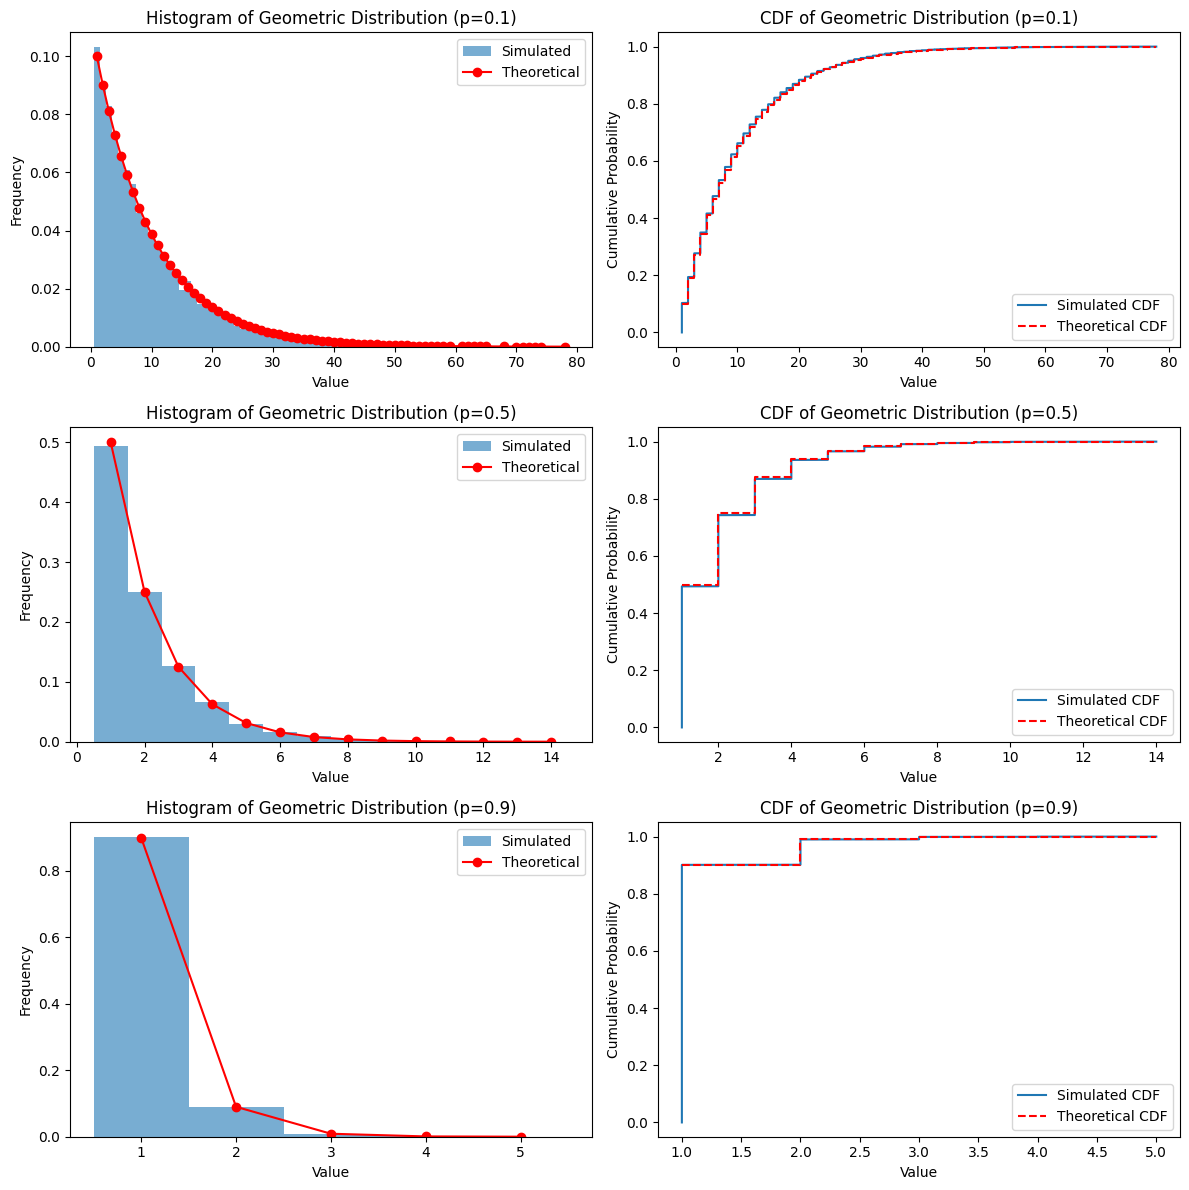

In [9]:
# Number of simulated values to generate
n_samples = 10000
np.random.seed(42)  # For reproducibility

import matplotlib.pyplot as plt

# Choose small, moderate, and large values for p
p_values = [0.1, 0.5, 0.9]

geom_samples = {}


fig, axes = plt.subplots(len(p_values), 2, figsize=(12, 12))

for i, p in enumerate(p_values):
    # Simulate observations
    samples = np.random.geometric(p, n_samples)
    geom_samples[p] = samples
    
    max_val = np.max(samples)
    bins = np.arange(0.5, max_val + 1.5, 1)

    values = np.unique(samples)
    theoretical_props = p * (1 - p)**(values - 1)

    # Chi-square test
    values, counts = np.unique(samples, return_counts=True)
    expected_counts = n_samples * theoretical_props

    # Normalize expected counts to match the sum of observed counts exactly
    expected_counts = expected_counts * np.sum(counts) / np.sum(expected_counts)

    chi2_stat, p_value = chisquare(counts, f_exp=expected_counts)

    print(f"Chi-square statistic for p={p}: {chi2_stat:.2f}, P-value: {p_value:.4f}")

    # Histogram of simulated vs theoretical
    axes[i, 0].hist(samples, bins=bins, density=True, alpha=0.6, label='Simulated')
    axes[i, 0].plot(values, theoretical_props, 'ro-', label='Theoretical')
    axes[i, 0].set_title(f'Histogram of Geometric Distribution (p={p})')
    axes[i, 0].set_xlabel('Value')
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].legend()
    
    # CDF of simulated vs theoretical
    sorted_samples = np.sort(samples)
    cdf = np.arange(1, n_samples + 1) / n_samples
    axes[i, 1].plot(sorted_samples, cdf, label='Simulated CDF')
    
    theoretical_cdf = 1 - (1 - p)**(values)
    axes[i, 1].step(values, theoretical_cdf, 'r--', where='post', label='Theoretical CDF')
    axes[i, 1].set_title(f'CDF of Geometric Distribution (p={p})')
    axes[i, 1].set_xlabel('Value')
    axes[i, 1].set_ylabel('Cumulative Probability')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

Chi-square statistic for Direct method: 5.80
Fail to reject null hypothesis for Direct method (good fit)
P-value for Direct method: 0.3261
Chi-square statistic for Rejection method: 3.34
Fail to reject null hypothesis for Rejection method (good fit)
P-value for Rejection method: 0.6478
Chi-square statistic for Alias method: 4.56
Fail to reject null hypothesis for Alias method (good fit)
P-value for Alias method: 0.4723


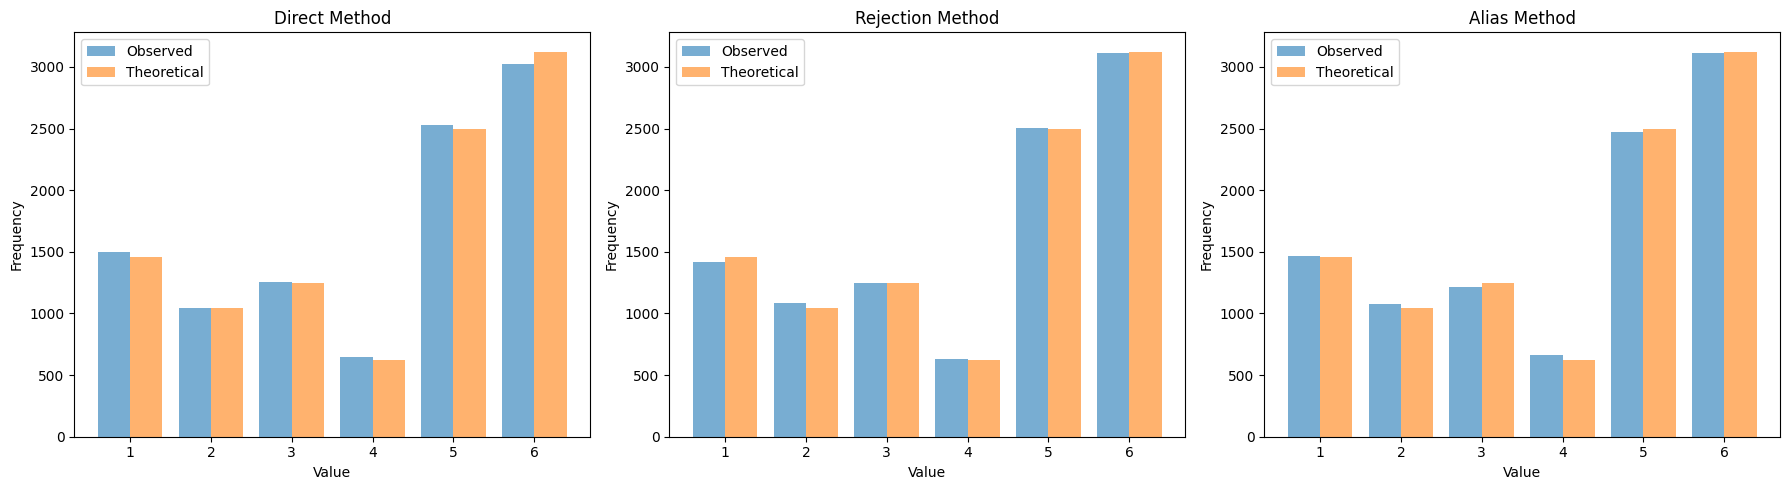


Accuracy Metrics:
Direct Method - Exec Time: 0.0352s, Total Variation Distance (TVD): 0.010300, RMSE: 0.004767
Rejection Method - Exec Time: 0.1151s, Total Variation Distance (TVD): 0.005533, RMSE: 0.002592
Alias Method - Exec Time: 0.0454s, Total Variation Distance (TVD): 0.007800, RMSE: 0.002803


In [ ]:
import time

x_i = np.array([1, 2, 3, 4, 5, 6])
p_i = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])
np.random.seed(42)  # For reproducibility



def direct_method(x_i, p_i, n_samples):
    F = np.cumsum(p_i)
    
    samples = []
    for _ in range(n_samples):
        u = np.random.uniform(0, 1)
        for i, f in enumerate(F):
            if u < f:
                samples.append(x_i[i])
                break
    return np.array(samples)

samples_direct = direct_method(x_i, p_i, n_samples)

def rejection_method(x_i, p_i, n_samples):
    c = np.max(p_i) + 0.0042
    samples = []
    k = len(x_i)


    while len(samples) < n_samples:
        u1 = np.random.uniform(0, 1)
        u2 = np.random.uniform(0, 1)

        I = np.floor(k * u1).astype(int) + 1

        if u2 < p_i[I - 1] / c:
            samples.append(x_i[I - 1])
            

    return np.array(samples)

samples_rejection = rejection_method(x_i, p_i, n_samples)

def table_alias(x_i, p_i):
    n = len(x_i)
    scaled_p = p_i * n
    alias = np.zeros(n, dtype=int)
    prob = np.zeros(n)
    
    small = []
    large = []
    
    for i in range(n):
        if scaled_p[i] < 1:
            small.append(i)
        else:
            large.append(i)
    
    while small and large:
        s = small.pop()
        l = large.pop()
        
        prob[s] = scaled_p[s]
        alias[s] = l
        
        scaled_p[l] = scaled_p[l] - (1 - prob[s])
        
        if scaled_p[l] < 1:
            small.append(l)
        else:
            large.append(l)
    
    for i in large + small:
        prob[i] = 1
    
    return alias, prob

alias, prob = table_alias(x_i, p_i)

def alias_method(x_i, alias, prob, n_samples):
    n = len(x_i)
    samples = []
    
    for _ in range(n_samples):
        i = np.random.randint(n)
        u = np.random.uniform(0, 1)
        
        if u < prob[i]:
            samples.append(x_i[i])
        else:
            samples.append(x_i[alias[i]])
    
    return np.array(samples)

samples_alias = alias_method(x_i, alias, prob, n_samples)


# show histograms with expected and observed frequencies
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
methods = ['Direct', 'Rejection', 'Alias']
samples_list = [samples_direct, samples_rejection, samples_alias]
theoretical_freq = p_i * n_samples
for i, samples in enumerate(samples_list):
    observed_freq = np.array([np.sum(samples == x) for x in x_i])
    
    axes[i].bar(x_i - 0.2, observed_freq, width=0.4, label='Observed', alpha=0.6)
    axes[i].bar(x_i + 0.2, theoretical_freq, width=0.4, label='Theoretical', alpha=0.6)
    axes[i].set_title(f'{methods[i]} Method')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

    chi2_statistic = chi_square_test(observed_freq, theoretical_freq)
    print(f"Chi-square statistic for {methods[i]} method: {chi2_statistic:.2f}")
    if chi2_statistic < chi2.ppf(conf_level, len(x_i) - 1):
        print(f"Fail to reject null hypothesis for {methods[i]} method (good fit)")
    else:
        print(f"Reject null hypothesis for {methods[i]} method (poor fit)")

    _, p_value = chisquare(observed_freq, f_exp=theoretical_freq)
    print(f"P-value for {methods[i]} method: {p_value:.4f}")    

plt.tight_layout()
plt.show()

print("\nAccuracy Metrics:")
for i, samples in enumerate(samples_list):
    observed_probs = np.array([np.sum(samples == x) for x in x_i]) / n_samples
    tvd = 0.5 * np.sum(np.abs(observed_probs - p_i))
    rmse = np.sqrt(np.mean((observed_probs - p_i)**2))
    start_time = time.perf_counter()
    if methods[i] == 'Direct':
        direct_method(x_i, p_i, n_samples)
    elif methods[i] == 'Rejection':
        rejection_method(x_i, p_i, n_samples)
    elif methods[i] == 'Alias':
        alias_method(x_i, alias, prob, n_samples)
    exec_time = time.perf_counter() - start_time
    
    print(f"{methods[i]} Method - Exec Time: {exec_time:.4f}s, Total Variation Distance (TVD): {tvd:.6f}, RMSE: {rmse:.6f}")

### Exercise 3

Generated 10000 samples for each distribution.
KS test p-value for Exponential distribution: 0.0859
KS test p-value for Normal distribution: 0.1257
KS test p-value for Pareto distribution (k=4): 0.4470
Fail to reject null hypothesis for Exponential distribution (good fit)
Fail to reject null hypothesis for Normal distribution (good fit)
Fail to reject null hypothesis for Pareto distribution (good fit)


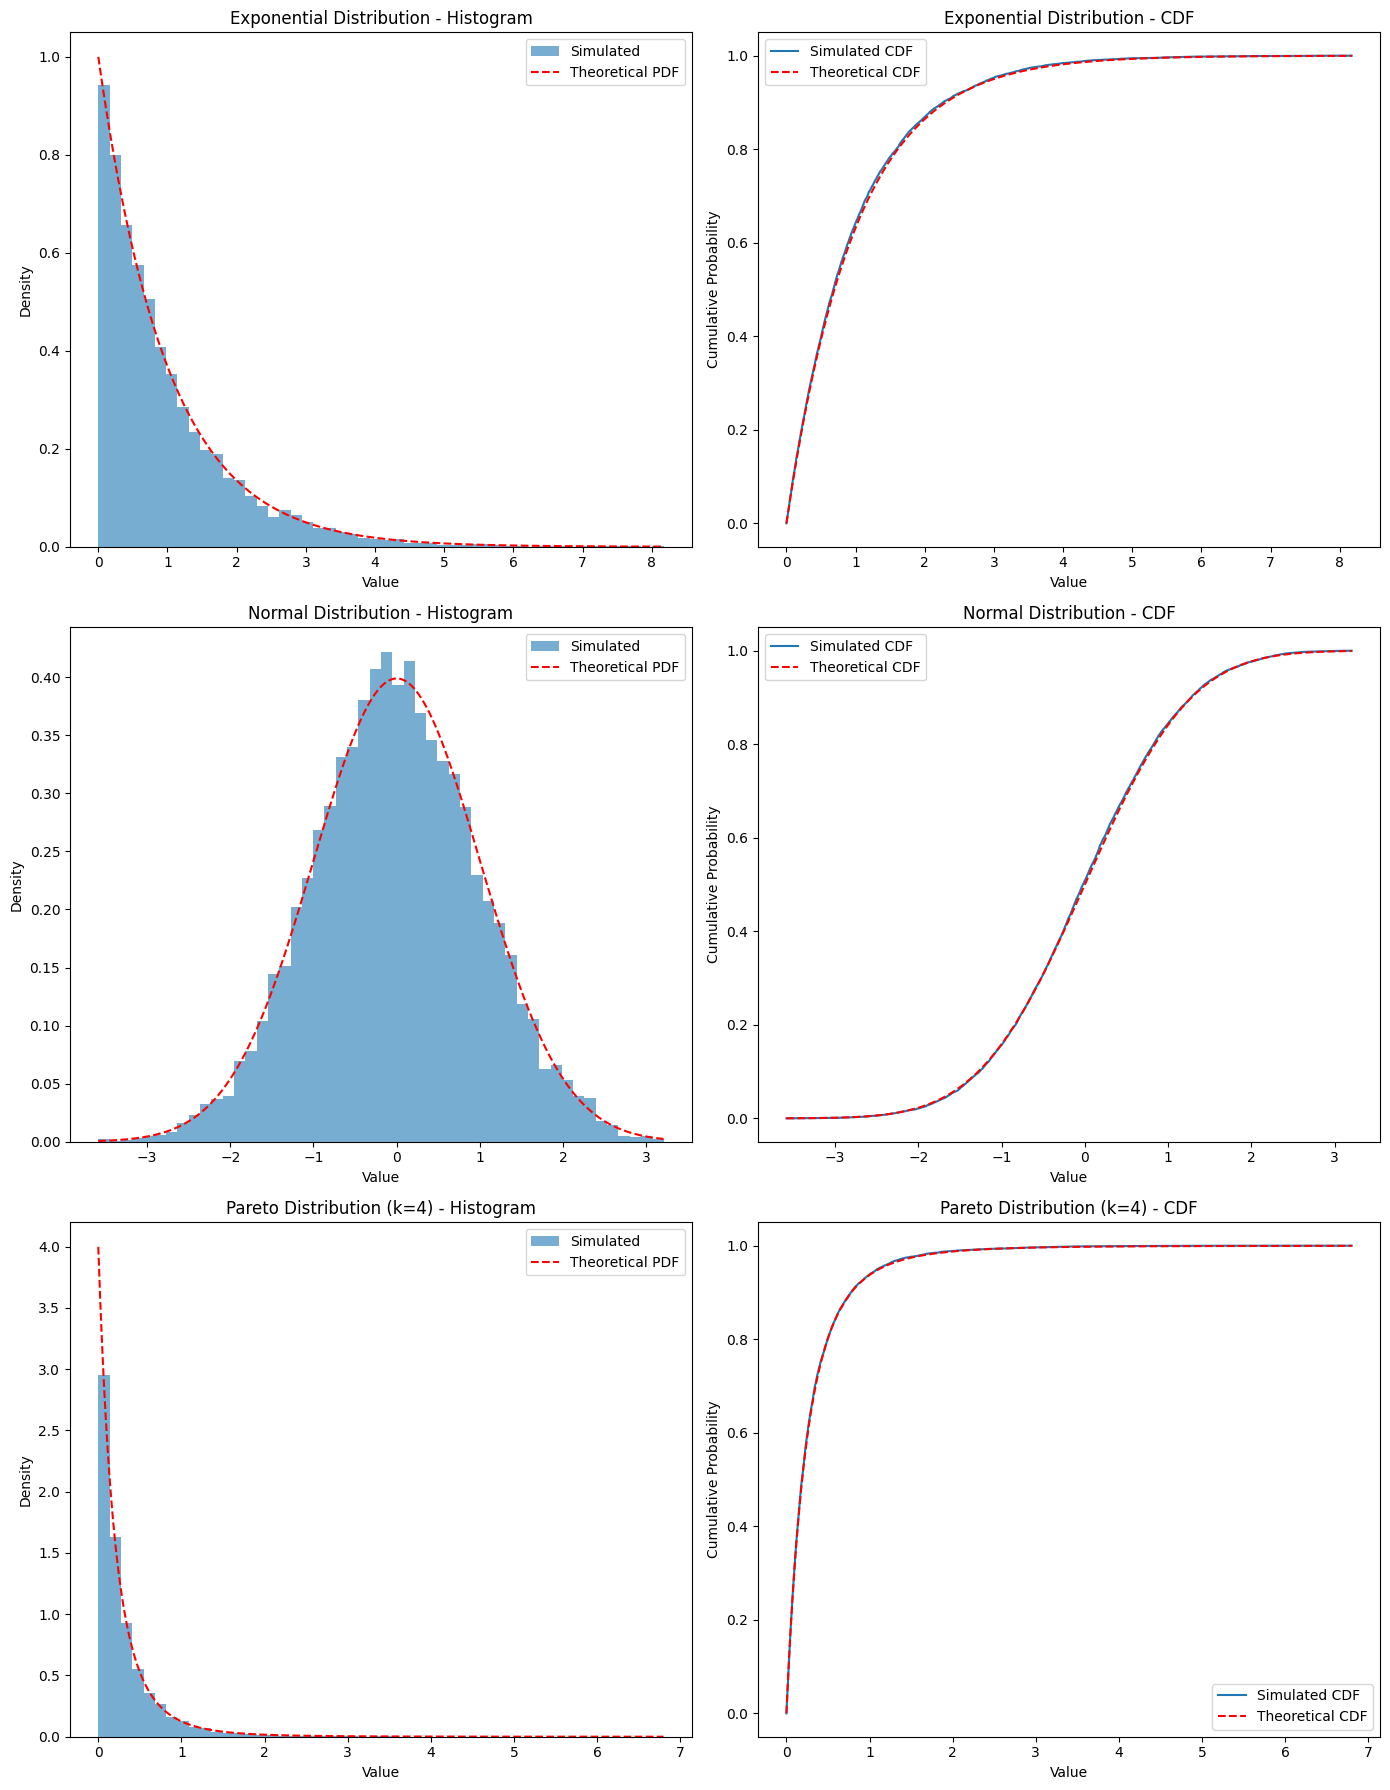

In [24]:
# (a) Exponential distribution using Inverse Transform Sampling
np.random.seed(42)  # For reproducibility
from scipy import stats
def generate_exponential(lam=1.0, size=n_samples):
    u = np.random.uniform(0, 1, size)
    return -np.log(1 - u) / lam

exp_samples = generate_exponential(lam=1.0, size=n_samples)

# (b) Normal distribution using Standard Box-Muller Transform
def generate_normal_box_muller(size=n_samples):
    # Only need size/2 pairs if size is even, but for simplicity we generate size pairs
    u1 = np.random.uniform(0, 1, size)
    u2 = np.random.uniform(0, 1, size)
    
    z0 = np.sqrt(-2.0 * np.log(u1)) * np.cos(2.0 * np.pi * u2)
    z1 = np.sqrt(-2.0 * np.log(u1)) * np.sin(2.0 * np.pi * u2)
    
    return z0, z1

norm_samples_z0, norm_samples_z1 = generate_normal_box_muller(n_samples)

# (c) Pareto distribution using Inverse Transform Sampling
def generate_pareto(k, beta=1.0, size=n_samples):
    u = np.random.uniform(0, 1, size)
    return beta * (u**(-1/k) - 1)

k_values = [2.05, 2.5, 3, 4]
pareto_samples = {}
for k_val in k_values:
    pareto_samples[k_val] = generate_pareto(k=k_val, beta=1, size=n_samples)

print(f"Generated {n_samples} samples for each distribution.")


# Plotting histograms and CDFs
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

distributions = [
    (stats.expon, (0, 1)), 
    (stats.norm, (0, 1)), 
    (stats.pareto, (4, -1, 1)) # loc=-1 perfectly matches beta*(u**(-1/k) - 1)
]

for i, (samples, dist_info, title) in enumerate(zip(
    [exp_samples, norm_samples_z0, pareto_samples[4]],
    distributions,
    ['Exponential Distribution', 'Normal Distribution', 'Pareto Distribution (k=4)']
)):
    dist_class, args = dist_info
    sorted_samples = np.sort(samples)
    theoretical_pdf = dist_class.pdf(sorted_samples, *args)
    theoretical_cdf = dist_class.cdf(sorted_samples, *args)

    # Histogram
    axes[i, 0].hist(samples, bins=50, density=True, alpha=0.6, label='Simulated')
    axes[i, 0].plot(sorted_samples, theoretical_pdf, 'r--', label='Theoretical PDF')
    axes[i, 0].set_title(f'{title} - Histogram')
    axes[i, 0].set_xlabel('Value')
    axes[i, 0].set_ylabel('Density')
    axes[i, 0].legend()
    
    # CDF
    cdf = np.arange(1, n_samples + 1) / n_samples
    axes[i, 1].plot(sorted_samples, cdf, label='Simulated CDF')
    
    axes[i, 1].plot(sorted_samples, theoretical_cdf, 'r--', label='Theoretical CDF')
    
    axes[i, 1].set_title(f'{title} - CDF')
    axes[i, 1].set_xlabel('Value')
    axes[i, 1].set_ylabel('Cumulative Probability')
    axes[i, 1].legend()


plt.tight_layout()

_, p_value_exp = kstest(exp_samples, 'expon', args=(0, 1))
_, p_value_norm = kstest(norm_samples_z0, 'norm', args=(0, 1))
_, p_value_pareto = kstest(pareto_samples[4], 'pareto', args=(4, -1, 1))
print(f"KS test p-value for Exponential distribution: {p_value_exp:.4f}")
print(f"KS test p-value for Normal distribution: {p_value_norm:.4f}")
print(f"KS test p-value for Pareto distribution (k=4): {p_value_pareto:.4f}")

if p_value_exp > 0.05:
    print("Fail to reject null hypothesis for Exponential distribution (good fit)")
else:    print("Reject null hypothesis for Exponential distribution (poor fit)")
if p_value_norm > 0.05:
    print("Fail to reject null hypothesis for Normal distribution (good fit)")
else:    print("Reject null hypothesis for Normal distribution (poor fit)")
if p_value_pareto > 0.05:
    print("Fail to reject null hypothesis for Pareto distribution (good fit)")
else:    print("Reject null hypothesis for Pareto distribution (poor fit)")

In [25]:
beta = 1.0

print("Pareto Distribution: Empirical vs Theoretical Moments (Support [β, ∞[)")
print(f"{'k':<5} | {'Empirical Mean':<14} | {'Theoretical Mean':<16} | {'Empirical Var':<13} | {'Theoretical Var'}")
print("-" * 75)

for k_val, samples in pareto_samples.items():
    # The previously generated samples have support [0, ∞[. 
    # We add beta to shift the support to [β, ∞[.
    standard_samples = samples + beta
    
    emp_mean = np.mean(standard_samples)
    emp_var = np.var(standard_samples, ddof=1)
    
    # Theoretical Mean (defined for k > 1)
    theo_mean = (beta * k_val) / (k_val - 1) if k_val > 1 else np.inf
        
    # Theoretical Variance (defined for k > 2)
    theo_var = (beta**2 * k_val) / (((k_val - 1)**2) * (k_val - 2)) if k_val > 2 else np.inf
        
    print(f"{k_val:<5} | {emp_mean:<14.4f} | {theo_mean:<16.4f} | {emp_var:<13.4f} | {theo_var:.4f}")

Pareto Distribution: Empirical vs Theoretical Moments (Support [β, ∞[)
k     | Empirical Mean | Theoretical Mean | Empirical Var | Theoretical Var
---------------------------------------------------------------------------
2.05  | 1.9923         | 1.9524           | 19.2591       | 37.1882
2.5   | 1.6763         | 1.6667           | 2.2675        | 2.2222
3     | 1.5021         | 1.5000           | 0.9063        | 0.7500
4     | 1.3272         | 1.3333           | 0.1869        | 0.2222


In [59]:
import numpy as np
from scipy import stats
np.random.seed(42)  # For reproducibility
n_intervals = 100
n_obs = 10
true_mean = 0.0
true_var = 1.0

# Generate 100 samples of 10 observations each from N(0, 1)
samples = np.random.normal(true_mean, np.sqrt(true_var), size=(n_intervals, n_obs))

sample_means = np.mean(samples, axis=1)
sample_vars = np.var(samples, axis=1, ddof=1)

# 95% CI for the mean using t-distribution (since population variance is estimated)
t_crit = stats.t.ppf(0.975, df=n_obs - 1)
mean_margin_of_error = t_crit * np.sqrt(sample_vars / n_obs)
ci_mean_lower = sample_means - mean_margin_of_error
ci_mean_upper = sample_means + mean_margin_of_error

# Check how many intervals contain the true mean
mean_coverage = np.sum((ci_mean_lower <= true_mean) & (ci_mean_upper >= true_mean))

# 95% CI for the variance using Chi-Square distribution
chi2_lower = stats.chi2.ppf(0.975, df=n_obs - 1)
chi2_upper = stats.chi2.ppf(0.025, df=n_obs - 1)
ci_var_lower = (n_obs - 1) * sample_vars / chi2_lower
ci_var_upper = (n_obs - 1) * sample_vars / chi2_upper

# Check how many intervals contain the true variance
var_coverage = np.sum((ci_var_lower <= true_var) & (ci_var_upper >= true_var))

print(f"Confidence Intervals containing true mean (0.0): {mean_coverage} / {n_intervals}")
print(f"Confidence Intervals containing true variance (1.0): {var_coverage} / {n_intervals}")
print("\nDiscussion:")
print("In a 95% confidence interval, we expect approximately 95 out of 100 generated intervals to contain the true population parameter.")
print(f"Observed coverage for mean: {mean_coverage}% (Expected ~95%)")
print(f"Observed coverage for variance: {var_coverage}% (Expected ~95%)")
print("Deviations from exactly 95 are due to random sampling variability in this specific simulation of 100 intervals.")

Confidence Intervals containing true mean (0.0): 95 / 100
Confidence Intervals containing true variance (1.0): 97 / 100

Discussion:
In a 95% confidence interval, we expect approximately 95 out of 100 generated intervals to contain the true population parameter.
Observed coverage for mean: 95% (Expected ~95%)
Observed coverage for variance: 97% (Expected ~95%)
Deviations from exactly 95 are due to random sampling variability in this specific simulation of 100 intervals.


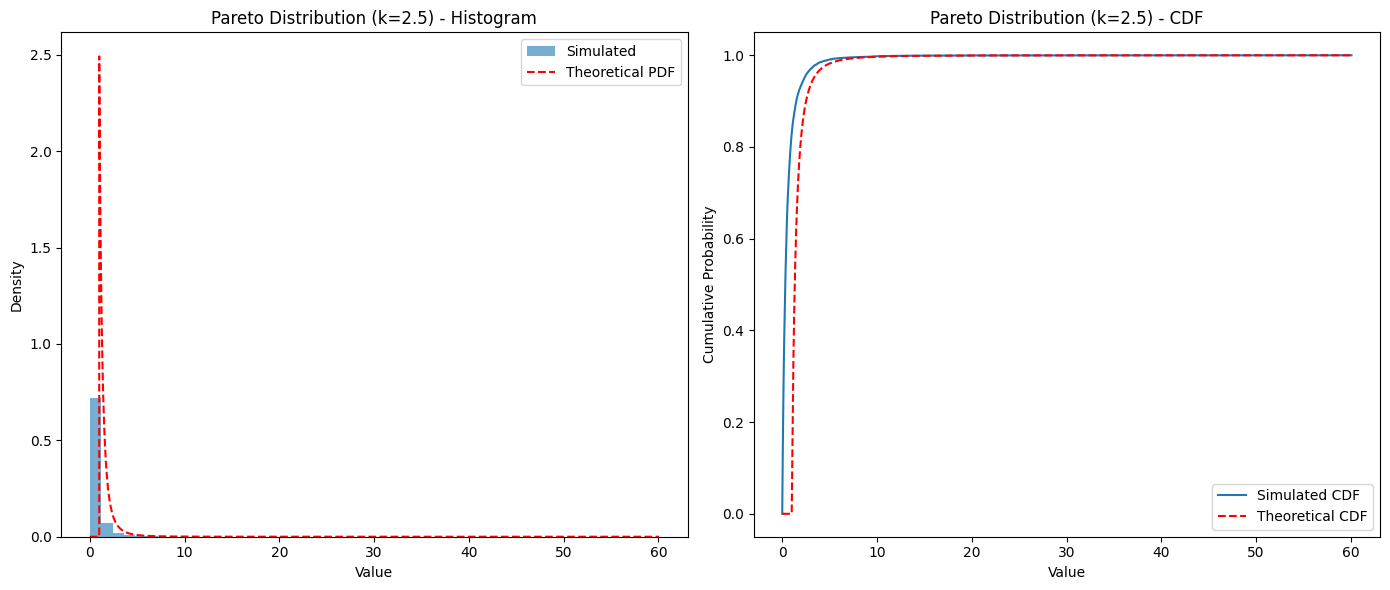

KS test p-value for Pareto distribution (k=2.5): 0.5975
Fail to reject null hypothesis for Pareto distribution (good fit)


In [80]:
### Simulate from the Pareto distribution using composition.
np.random.seed(42)  # For reproducibility
def sample_pareto_via_mixture(n, alpha, beta):
    """
    Generates samples from a Pareto (Lomax) distribution 
    using the mixture of exponentials representation.
    """
    # 1. Sample the rate parameter lambda from a Gamma distribution
    # Note: Using shape=alpha, scale=1/beta
    lambdas = np.random.gamma(shape=alpha, scale=1.0/beta, size=n)
    
    # 2. Sample from Exponential(lambda)
    samples = np.random.exponential(scale=1.0/lambdas)
    
    return samples
    
theoretical_samples = generate_pareto(k=2.5, beta=1.0, size=n_samples)

samples = sample_pareto_via_mixture(n_samples, alpha=2.5, beta=1.0)
# Plotting histograms and CDFs
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sorted_samples = np.sort(samples)
theoretical_pdf = stats.pareto.pdf(sorted_samples, 2.5)
theoretical_cdf = stats.pareto.cdf(sorted_samples, 2.5)
# Histogram
axes[0].hist(samples, bins=50, density=True, alpha=0.6, label='Simulated')
axes[0].plot(sorted_samples, theoretical_pdf, 'r--', label='Theoretical PDF')
axes[0].set_title('Pareto Distribution (k=2.5) - Histogram')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].legend()

# CDF
cdf = np.arange(1, n_samples + 1) / n_samples
axes[1].plot(sorted_samples, cdf, label='Simulated CDF')
axes[1].plot(sorted_samples, theoretical_cdf, 'r--', label='Theoretical CDF')
axes[1].set_title('Pareto Distribution (k=2.5) - CDF')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Cumulative Probability')
axes[1].legend()
plt.tight_layout()
plt.show()

# KS test for goodness of fit
_, p_value = kstest(samples, 'pareto', args=(2.5, -1, 1))
print(f"KS test p-value for Pareto distribution (k=2.5): {p_value:.4f}")
if p_value > 0.05:
    print("Fail to reject null hypothesis for Pareto distribution (good fit)")
else:    print("Reject null hypothesis for Pareto distribution (poor fit)")